<a href="https://colab.research.google.com/github/TheHoneyBoy/Analisis-de-expresion-genica-para-identificacion-de-genes-diferencialmente-expresados/blob/back_Gian/BIO_MERGED_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd
import requests
from io import BytesIO

# URL RAW del archivo en GitHub (asegúrate que termine en .xlsx y sea raw)
url = "https://github.com/TheHoneyBoy/Analisis-de-expresion-genica-para-identificacion-de-genes-diferencialmente-expresados/raw/refs/heads/backend_Paul/data/GSE180440_Processed_data.xlsx"

# Descargar el archivo
response = requests.get(url)

# Verificar que se descargó correctamente
if response.status_code == 200:
    # Leer el archivo como Excel desde memoria
    data = pd.read_excel(BytesIO(response.content), skiprows=1, engine='openpyxl')
    print(data.head())
else:
    print(f"Error al descargar el archivo: {response.status_code}")


           Sample ID        File                paired   Location  \
0             PG3_19  1366 tumor  Normal tissue paired    SIGMOID   
1    1429_T_sequence  1429 tumor  Normal tissue paired    SIGMOID   
2             PG3_20  1789 tumor  Normal tissue paired  ASCENDING   
3             PG8_52  1792 tumor                   NaN  ASCENDING   
4  C_1800_T_sequence  1800 tumor                   NaN  ASCENDING   

   TUMOR CONTENT (%) Gender  Age Stage  T   N  ...    APC.3  FBXW7.1  \
0               60.0      F   60    II  3   0  ...  3.80965  5.92441   
1               80.0      M   64   III  3  1a  ...  1.69601  7.31190   
2               80.0      F   62    II  3   0  ...  1.22044  4.08102   
3               80.0      F   30    II  3   0  ...  3.19551  6.34322   
4               70.0      F   75   III  3  2b  ...  3.08477  4.99491   

     PTEN.1  SMAD4.1  SMAD2.1   SMAD3.1 TGFBR2.1  TCF7L2.1 ACVR2A.1    BAX.1  
0   9.94152  3.85690  4.38889  10.30700  28.7379   7.35724  3.86189  47.0

In [3]:
metadata_columns = [
    'Sample ID', 'File', 'paired', 'Location', 'TUMOR CONTENT (%)', 'Gender', 'Age',
    'Stage', 'T', 'N', 'M', 'MSS', 'APC'
]

# Filtrar solo columnas de genes (excluyendo metadatos)
gene_columns = [col for col in data.columns if col not in metadata_columns]
gene_data = data[gene_columns]


In [4]:
gene_data

,LGR5,CTNNB1,DVL1,AXIN1,GSK3B,AXIN2,FZD1,FZD2,FZD3,FZD4,...,APC.3,FBXW7.1,PTEN.1,SMAD4.1,SMAD2.1,SMAD3.1,TGFBR2.1,TCF7L2.1,ACVR2A.1,BAX.1
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.80965,5.92441,9.94152,3.85690,4.38889,10.30700,28.7379,7.35724,3.86189,47.0384
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.69601,7.31190,7.87532,5.52607,5.21600,6.72191,28.6382,5.44369,3.61059,47.9410
2,0,NaN,f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.22044,4.08102,12.22160,7.61665,9.41556,6.81939,10.1895,9.43837,3.62809,72.5936
3,1,NaN,NaN,NaN,NaN,E728*,NaN,A244T,NaN,W327C,...,3.19551,6.34322,10.43280,9.13184,6.39047,7.87174,26.2317,9.72757,2.57826,51.9455
4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.08477,4.99491,4.09546,5.22404,5.70172,10.62120,26.5727,12.36520,2.34317,82.2761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.98547,9.82085,7.90861,5.12109,3.68383,9.31672,29.0137,7.86534,3.51077,92.5596
141,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.68679,11.72780,8.65230,3.43655,4.14870,8.06257,26.0300,11.07220,1.69603,65.1503
142,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.05116,4.82387,6.59332,4.28110,3.77052,7.50665,20.3009,7.11344,2.35824,88.1253
143,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.89845,6.29577,7.25935,2.92682,3.62546,8.83396,19.8542,16.54900,1.51960,71.6826


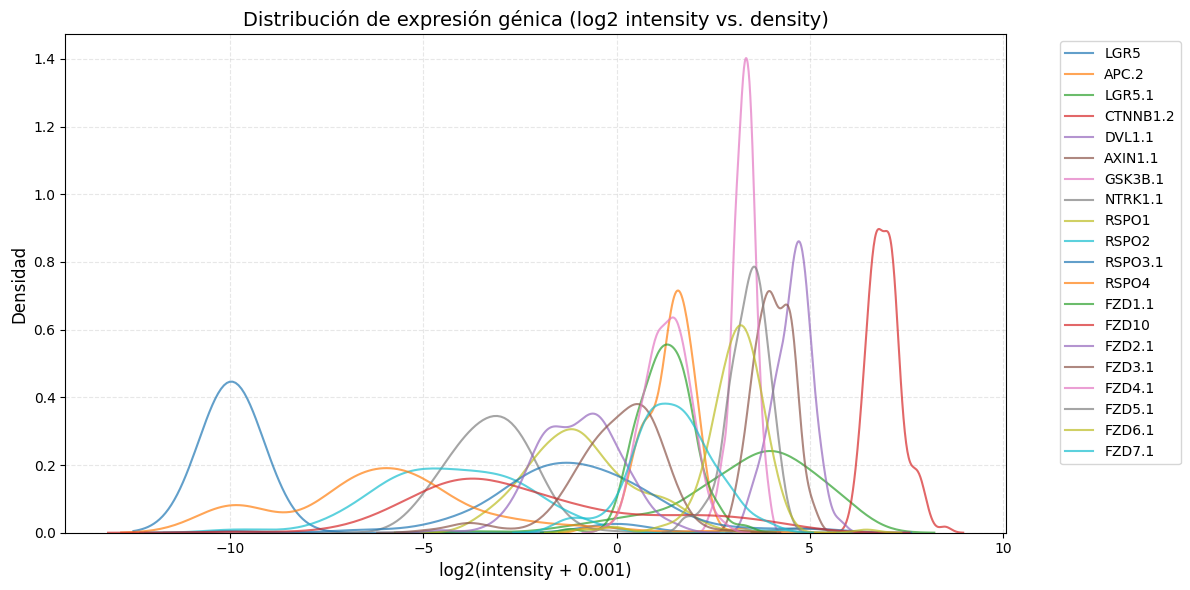

In [5]:
# Filtrar columnas de genes y eliminar las que tienen NaN
gene_data = data.drop(columns=metadata_columns).dropna(axis=1)  # axis=1 para columnas
log_gene_data = gene_data.apply(lambda x: np.log2(x + 1e-3))  # Añade un pequeño offset para evitar -inf

# 3. Configurar el gráfico de densidad (log intensity vs. density)
plt.figure(figsize=(12, 6))
for gene in log_gene_data.columns[:20]:  # Graficar solo los primeros 20 genes
    sns.kdeplot(log_gene_data[gene], label=gene, alpha=0.7, linewidth=1.5)

# 4. Personalizar el gráfico
plt.title("Distribución de expresión génica (log2 intensity vs. density)", fontsize=14)
plt.xlabel("log2(intensity + 0.001)", fontsize=12)  # Ajusta el offset según tu dato
plt.ylabel("Densidad", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

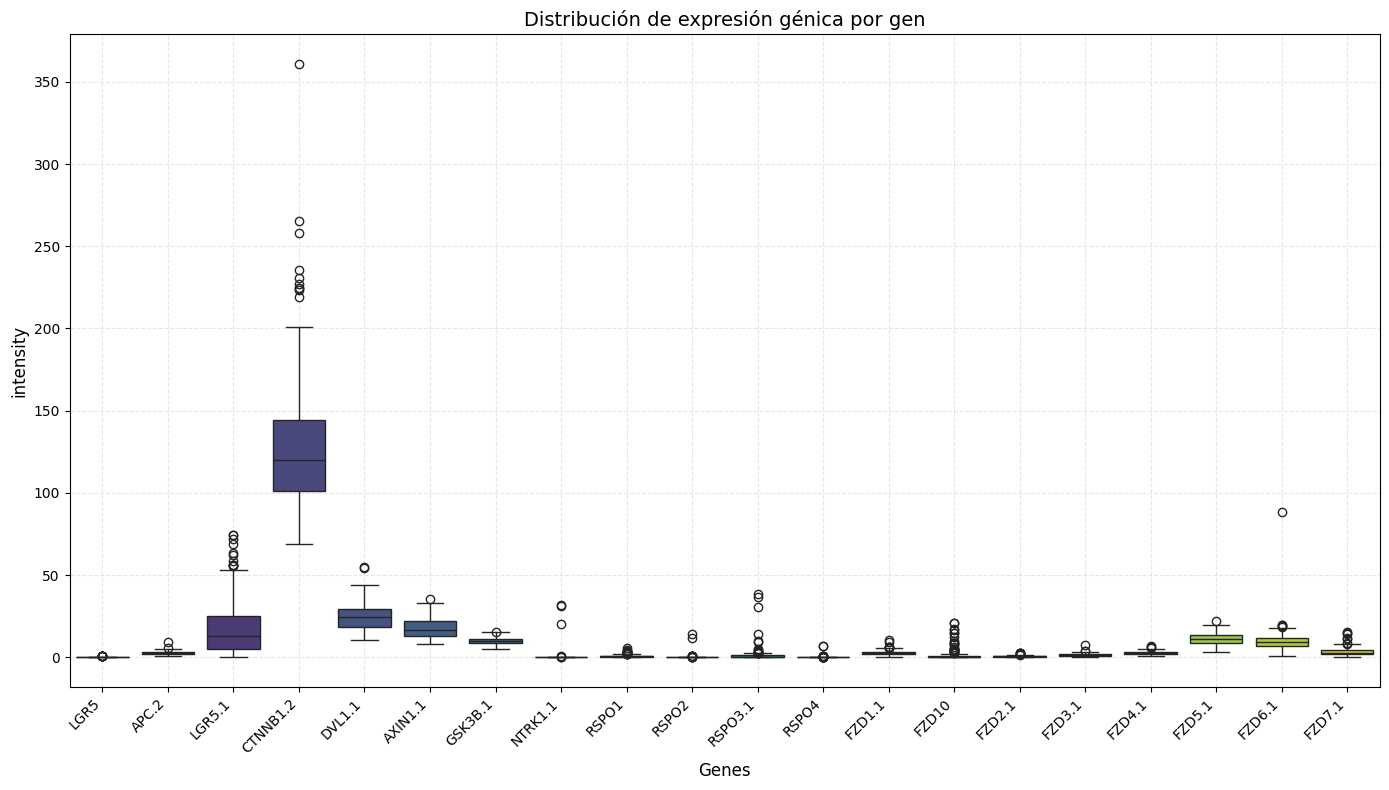

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el gráfico de boxplot
plt.figure(figsize=(14, 8))

# 2. Crear el boxplot para los primeros 20 genes (ajusta el número si es necesario)
sns.boxplot(data=gene_data.iloc[:, :20], palette="viridis")  # Usamos solo las primeras 20 columnas (genes)

# 3. Personalizar el gráfico
plt.title("Distribución de expresión génica por gen", fontsize=14)
plt.xlabel("Genes", fontsize=12)
plt.ylabel("intensity", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje X para mejor legibilidad
plt.grid(True, linestyle='--', alpha=0.3)

# 4. Ajustar layout y mostrar
plt.tight_layout()
plt.show()


=== Exportando datos para Persona 2 ===
✓ Datos normalizados con el método 'log2' guardados exitosamente en 'data_normalizado.csv'.

Vista previa de los datos exportados:
   Sample_ID sample_type     GEN_1     GEN_2     GEN_3     GEN_4     GEN_5  \
0  Muestra_0       TUMOR -0.601876  0.302963 -4.169070  1.098613  0.083563   
1  Muestra_1      NORMAL -0.584962  0.948499 -2.263907 -1.218246 -2.607584   
2  Muestra_2       TUMOR -0.285301  1.340839 -4.394741 -2.201734 -1.230636   
3  Muestra_3      NORMAL -2.499437 -1.710937 -0.398067 -1.031624  0.099522   
4  Muestra_4       TUMOR  0.051342 -2.981712 -1.143284  0.739164 -2.716192   

      GEN_6     GEN_7     GEN_8  ...    GEN_41    GEN_42    GEN_43    GEN_44  \
0 -0.446529 -0.983630 -0.997980  ...  1.015240  0.415848  0.555569 -3.390595   
1 -0.732184  1.092916  0.151435  ...  1.403675 -0.795225 -0.537202  0.947176   
2  0.183530  0.883773 -2.164188  ... -1.941989  0.492902  0.194906 -4.194025   
3 -0.758699  0.577976  0.323456  ...  0

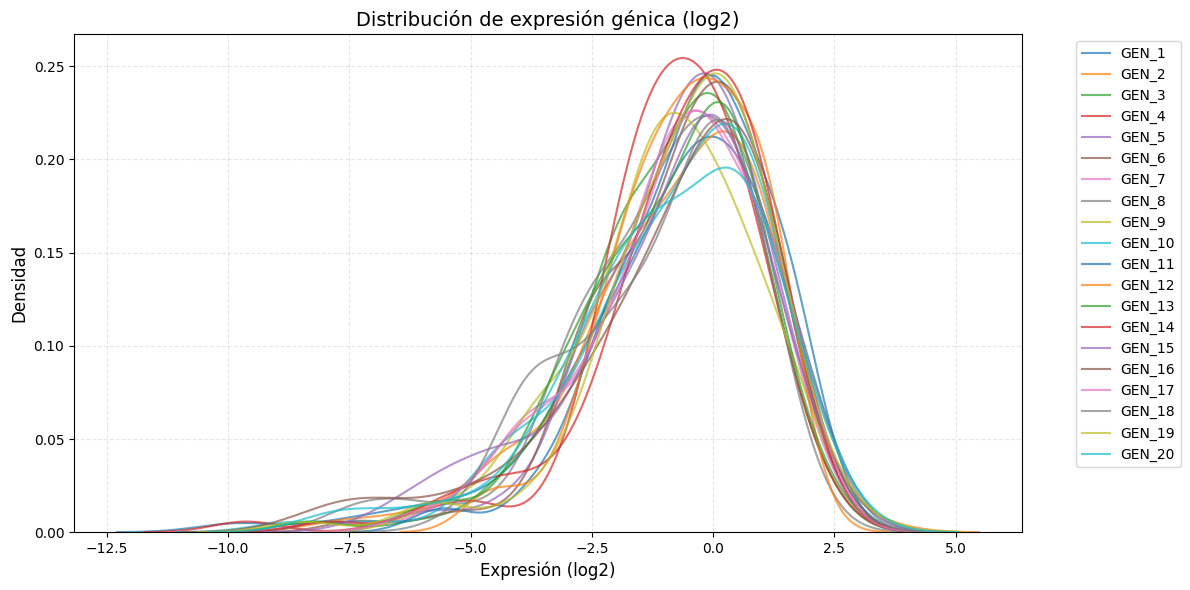

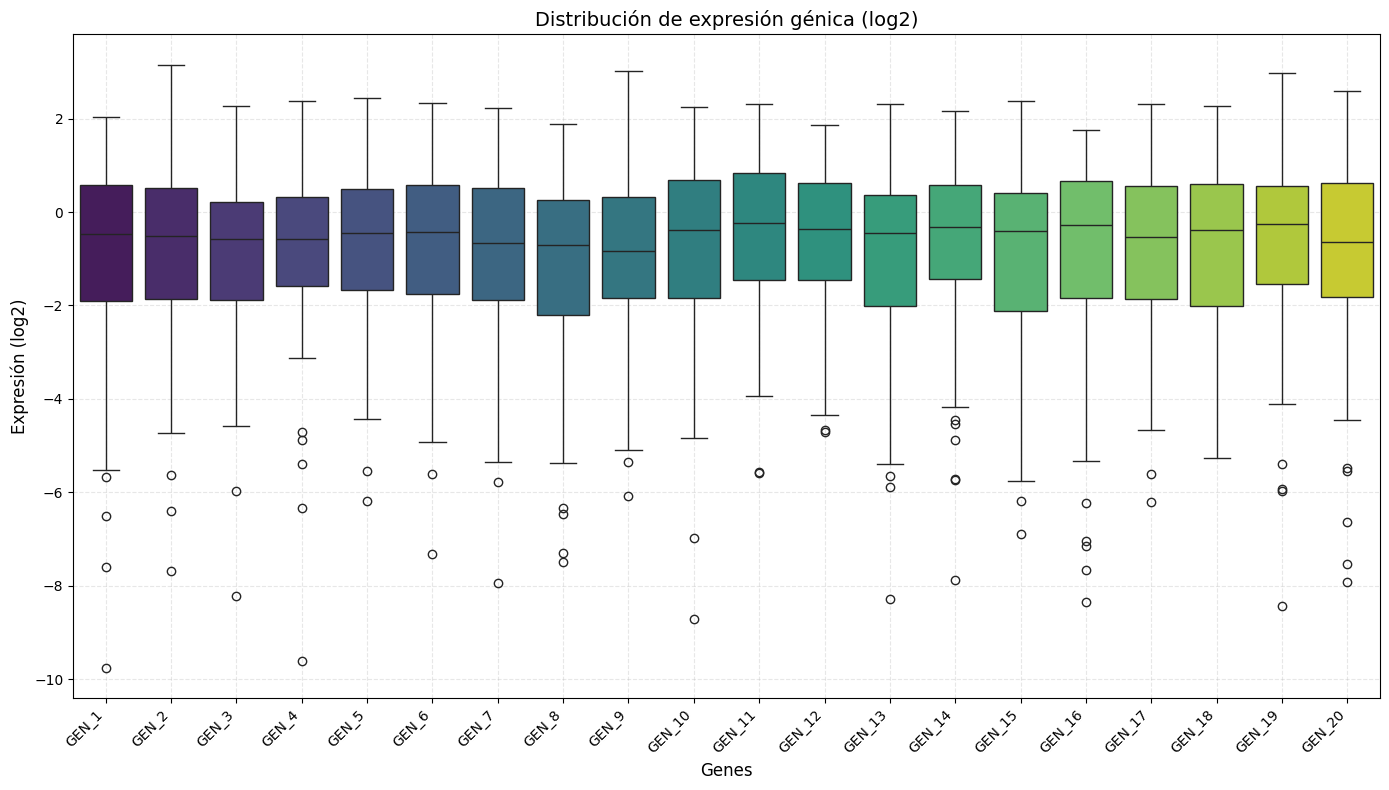


=== Visualización con normalización zscore ===


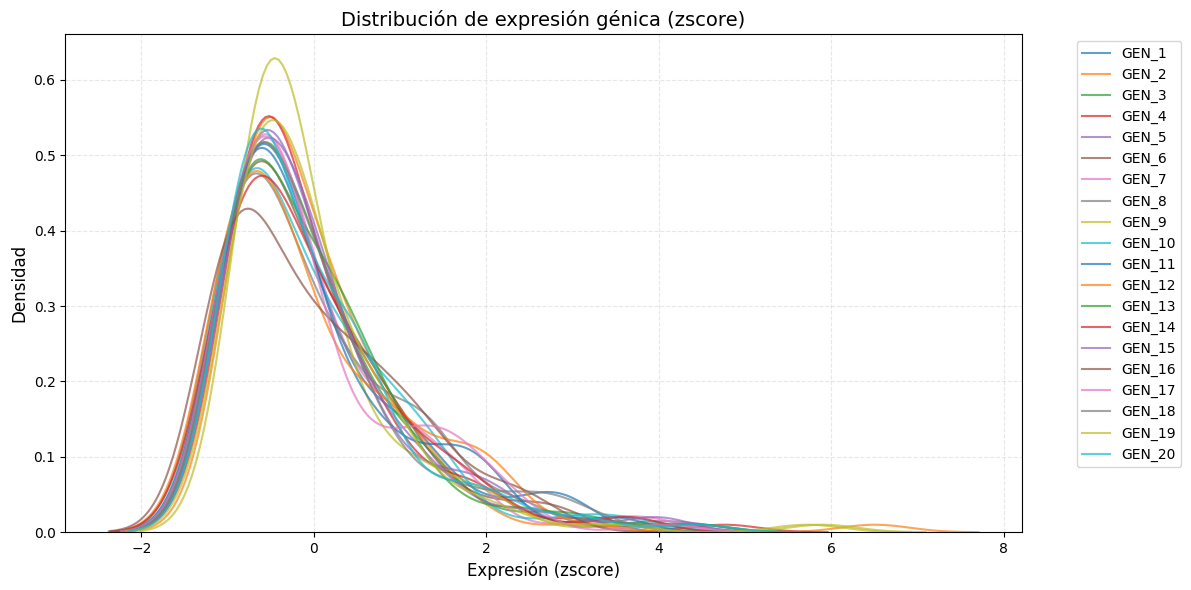

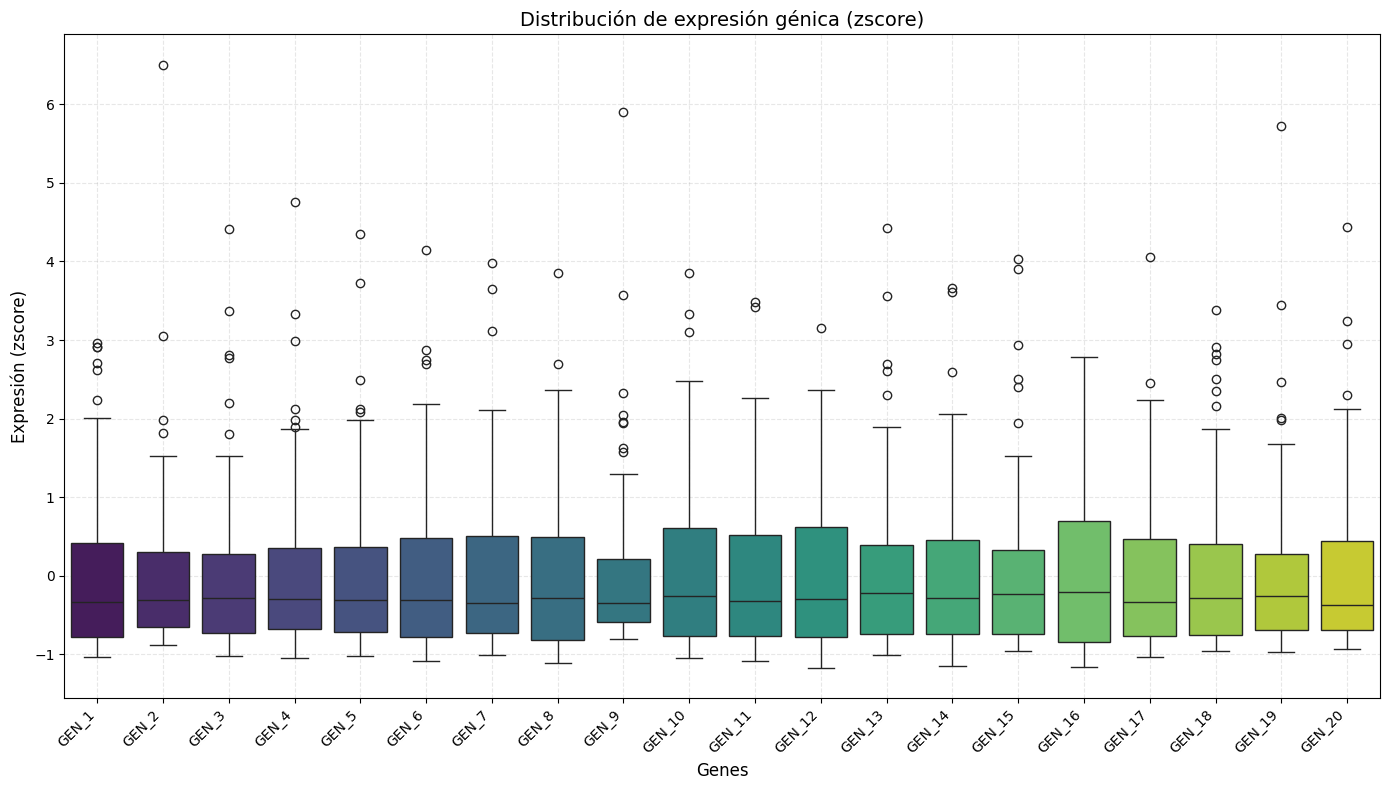


=== Visualización con normalización robust ===


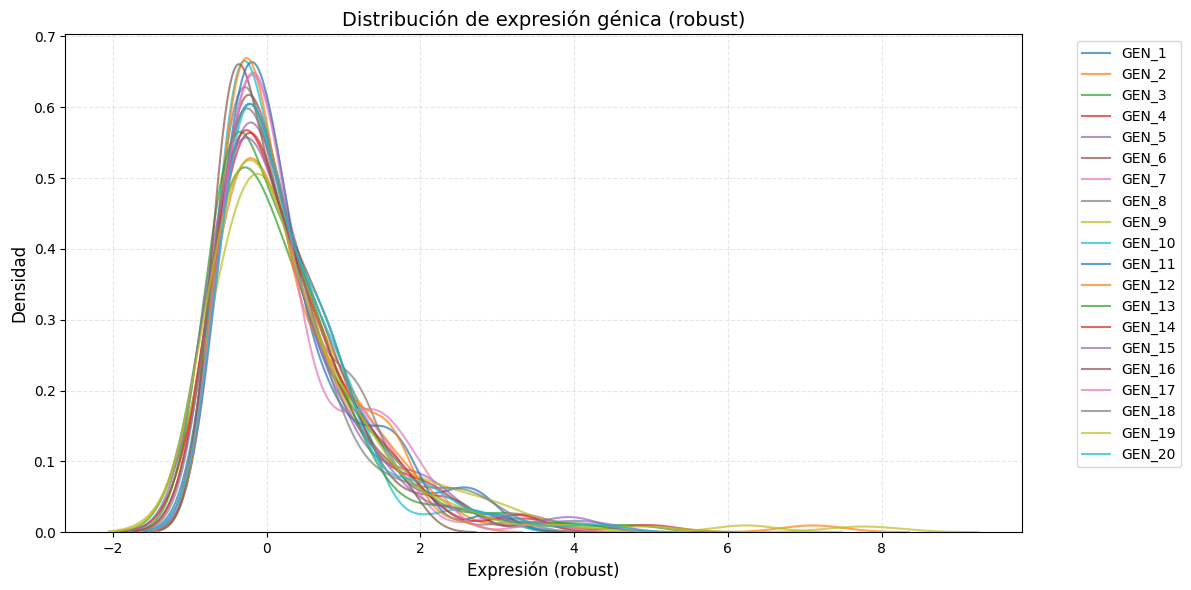

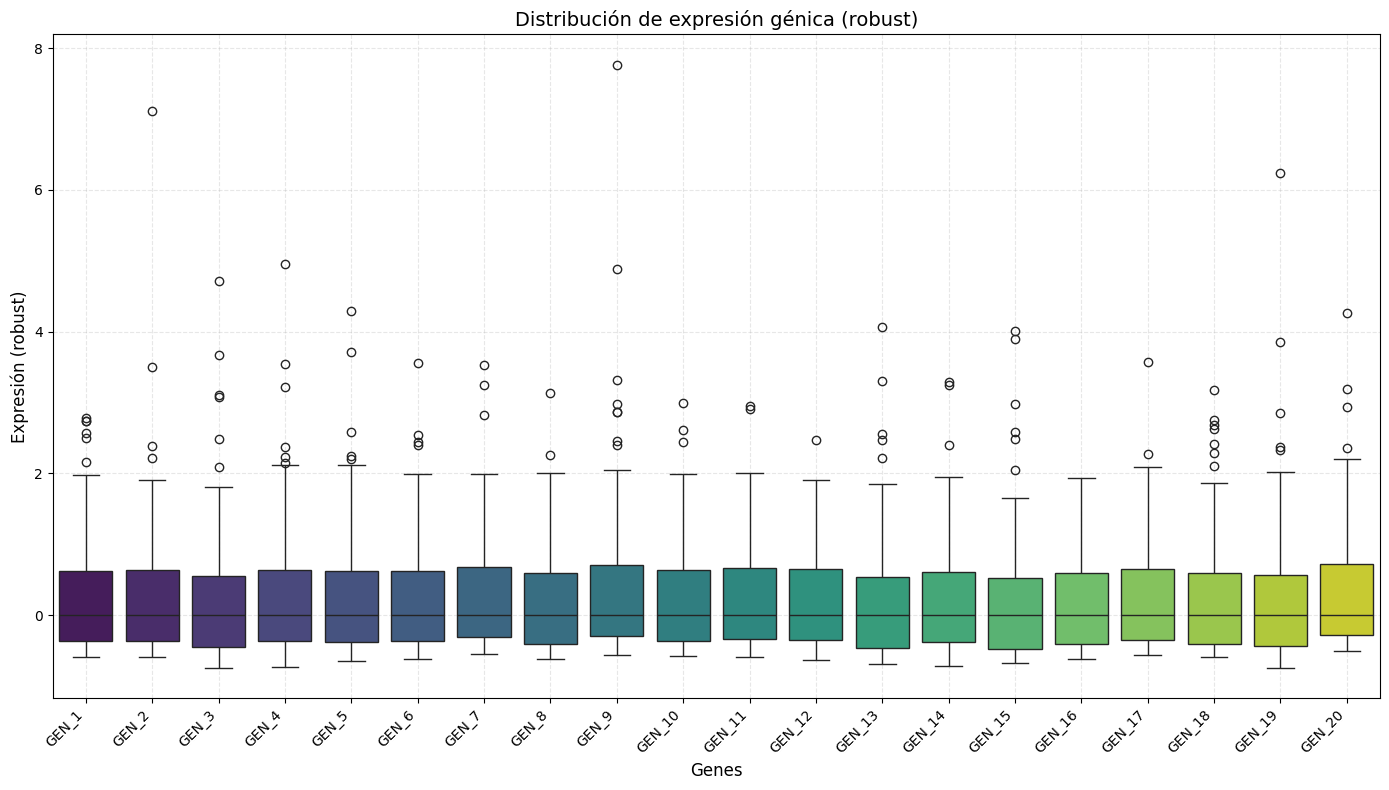

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler

class GeneExpressionVisualizer:
    def __init__(self, data, metadata_columns=None):
        """
        Inicializa el visualizador con datos de expresión génica.

        Parámetros:
        - data: DataFrame con los datos de expresión (genes en columnas)
        - metadata_columns: Lista de columnas que no son genes (opcional)
        """
        self.raw_data = data.copy()
        self.metadata_columns = metadata_columns or []
        self.gene_data = self._preprocess_data()

    def _preprocess_data(self):
        """Filtra columnas no génicas y elimina genes con NaN"""
        gene_cols = [col for col in self.raw_data.columns if col not in self.metadata_columns]
        return self.raw_data[gene_cols].dropna(axis=1)

    def normalize_data(self, method='log2'):
        """
        Normaliza los datos según el método especificado.

        Parámetros:
        - method: 'log2', 'zscore' o 'robust'

        Retorna:
        - DataFrame normalizado
        """
        data = self.gene_data.copy()

        if method == 'log2':
            # Normalización log2 con pequeño offset para evitar -inf
            return data.apply(lambda x: np.log2(x + 1e-3))

        elif method == 'zscore':
            # Estandarización z-score (media=0, desviación=1)
            scaler = StandardScaler()
            return pd.DataFrame(scaler.fit_transform(data),
                                columns=data.columns,
                                index=data.index)

        elif method == 'robust':
            # Escalado robusto (usa medianas y rangos intercuartílicos)
            scaler = RobustScaler()
            return pd.DataFrame(scaler.fit_transform(data),
                                columns=data.columns,
                                index=data.index)

        else:
            raise ValueError("Método de normalización no válido. Use 'log2', 'zscore' o 'robust'")

    def exportar_datos_normalizados(self, method='log2', ruta_salida='data_normalizado.csv'):
        """
        Normaliza los datos, los combina con los metadatos y los exporta a un CSV.

        Parámetros:
        - method (str): Método de normalización a aplicar ('log2', 'zscore', 'robust').
        - ruta_salida (str): Nombre del archivo CSV de salida.
        """
        # 1. Normalizar los datos de genes
        datos_genes_norm = self.normalize_data(method)

        # 2. Extraer los metadatos del DataFrame original
        metadata_df = self.raw_data[self.metadata_columns]

        # 3. Combinar metadatos y datos de genes normalizados
        # Se usa `join` para asegurar que las filas se alineen correctamente por el índice.
        datos_completos_norm = metadata_df.join(datos_genes_norm)

        # 4. Guardar en un archivo CSV
        datos_completos_norm.to_csv(ruta_salida, index=False)
        print(f"✓ Datos normalizados con el método '{method}' guardados exitosamente en '{ruta_salida}'.")
        return datos_completos_norm

    def plot_density(self, method='log2', genes=None, figsize=(12, 6)):
        """
        Grafica distribuciones de densidad para los genes.
        """
        norm_data = self.normalize_data(method)
        genes_to_plot = genes if genes is not None else norm_data.columns[:20]

        plt.figure(figsize=figsize)
        for gene in genes_to_plot:
            sns.kdeplot(norm_data[gene], label=gene, alpha=0.7, linewidth=1.5)

        plt.title(f"Distribución de expresión génica ({method})", fontsize=14)
        plt.xlabel(f"Expresión ({method})", fontsize=12)
        plt.ylabel("Densidad", fontsize=12)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_boxplot(self, method='log2', genes=None, figsize=(14, 8)):
        """
        Grafica boxplots para los genes.
        """
        norm_data = self.normalize_data(method)
        genes_to_plot = genes if genes is not None else norm_data.columns[:20]

        plt.figure(figsize=figsize)
        sns.boxplot(data=norm_data[genes_to_plot], palette="viridis")

        plt.title(f"Distribución de expresión génica ({method})", fontsize=14)
        plt.xlabel("Genes", fontsize=12)
        plt.ylabel(f"Expresión ({method})", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()


# Ejemplo de uso:
if __name__ == "__main__":
    # Datos de ejemplo (simulados)
    data = pd.DataFrame(np.random.exponential(size=(100, 50)),
                        columns=[f"GEN_{i}" for i in range(1, 51)])
    metadata = pd.DataFrame({
        "Sample_ID": [f"Muestra_{i}" for i in range(100)],
        "sample_type": np.random.choice(["TUMOR", "NORMAL"], size=100)
    })
    data_with_meta = pd.concat([metadata, data], axis=1)

    # Crear visualizador
    visualizer = GeneExpressionVisualizer(data_with_meta, metadata_columns=["Sample_ID", "sample_type"])

    # --- Exportación de datos ---
    # Se exportan los datos con la normalización 'log2' que necesita Persona 2.
    print("\n=== Exportando datos ===")
    datos_exportados = visualizer.exportar_datos_normalizados(method='log2', ruta_salida='data_normalizado.csv')

    print("\nVista previa de los datos exportados:")
    print(datos_exportados.head())

    # --- Visualización de todas las normalizaciones ---
    # Se generan los gráficos para todos los métodos de normalización disponibles.
    for norm_method in ['log2', 'zscore', 'robust']:
        print(f"\n=== Visualización con normalización {norm_method} ===")
        visualizer.plot_density(method=norm_method)
        visualizer.plot_boxplot(method=norm_method)


## CODE GIAN

In [12]:
# -*- coding: utf-8 -*-
"""
Módulo de Análisis Estadístico para Identificación de Genes Diferencialmente Expresados.
Responsable: Persona 2

Funcionalidad:
1. Carga los datos normalizados generados por Persona 1.
2. Realiza pruebas estadísticas (t-test de Student) para comparar grupos.
3. Calcula el Log2 Fold Change (log2FC).
4. Ajusta los p-valores para corrección de pruebas múltiples (FDR Benjamini-Hochberg).
5. Identifica y filtra genes significativamente diferenciales.
6. Guarda los resultados en un archivo CSV para ser consumido por Persona 3.
"""

import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np
import os

# =============================================================================
# BLOQUE 1: CLASE PARA EL ANÁLISIS ESTADÍSTICO
# =============================================================================

class AnalisisEstadistico:
    """
    Encapsula la lógica para el análisis de expresión génica diferencial.
    """
    def __init__(self, ruta_datos_normalizados):
        """
        Inicializa la clase cargando los datos normalizados.

        Args:
            ruta_datos_normalizados (str): Ruta al archivo CSV con los datos
                                           normalizados y metadatos.
        """
        try:
            self.datos_df = pd.read_csv(ruta_datos_normalizados)
            print("✓ Datos normalizados cargados exitosamente.")
            print(f"Dimensiones de los datos: {self.datos_df.shape}")
        except FileNotFoundError:
            print(f"Error: No se encontró el archivo en la ruta: {ruta_datos_normalizados}")
            print("Asegúrate de que el script de Persona 1 se haya ejecutado y generado el archivo.")
            self.datos_df = None

    def realizar_analisis_diferencial(self, columna_grupo, grupo1, grupo2, metadata_cols):
        """
        Realiza el análisis estadístico completo para encontrar genes diferenciales.

        Args:
            columna_grupo (str): Nombre de la columna de metadatos que define los grupos.
            grupo1 (str): Nombre del primer grupo (ej. 'TUMOR').
            grupo2 (str): Nombre del segundo grupo (ej. 'NORMAL').
            metadata_cols (list): Lista de nombres de columnas que son metadatos.

        Returns:
            pandas.DataFrame: Un DataFrame con los resultados del análisis para cada gen,
                              incluyendo p-valor, log2FC y p-valor ajustado.
                              Retorna None si los datos no se cargaron correctamente.
        """
        if self.datos_df is None:
            return None

        # 1. Separar los datos en los dos grupos de comparación
        grupo1_df = self.datos_df[self.datos_df[columna_grupo] == grupo1]
        grupo2_df = self.datos_df[self.datos_df[columna_grupo] == grupo2]

        if grupo1_df.empty or grupo2_df.empty:
            print(f"Error: Uno o ambos grupos ('{grupo1}', '{grupo2}') están vacíos.")
            print("Verifica los nombres de los grupos y el contenido de la columna de metadatos.")
            return None

        print(f"Análisis entre '{grupo1}' ({len(grupo1_df)} muestras) y '{grupo2}' ({len(grupo2_df)} muestras).")

        # 2. Identificar las columnas de genes
        columnas_genes = [col for col in self.datos_df.columns if col not in metadata_cols]

        resultados = []

        # 3. Iterar sobre cada gen para realizar el análisis
        for gen in columnas_genes:
            # Extraer los valores de expresión para cada grupo
            expresion_grupo1 = grupo1_df[gen].dropna()
            expresion_grupo2 = grupo2_df[gen].dropna()

            # Realizar t-test de Student (asumiendo varianzas desiguales)
            stat, p_valor = ttest_ind(expresion_grupo1, expresion_grupo2, equal_var=False, nan_policy='omit')

            # Calcular medias y Log2 Fold Change (log2FC)
            # Asumimos que los datos ya están en escala log2, como indica el proceso de Persona 1.
            # Por lo tanto, log2FC = media(log2(grupo1)) - media(log2(grupo2))
            media_grupo1 = expresion_grupo1.mean()
            media_grupo2 = expresion_grupo2.mean()
            log2fc = media_grupo1 - media_grupo2

            resultados.append({
                'gen': gen,
                'log2_fold_change': log2fc,
                'p_valor': p_valor,
            })

        # 4. Convertir resultados a DataFrame y ajustar p-valores
        resultados_df = pd.DataFrame(resultados)
        resultados_df = resultados_df.dropna(subset=['p_valor']) # Eliminar genes con p-valor NaN

        if resultados_df.empty:
            print("No se pudieron calcular p-valores para ningún gen.")
            return None

        # Usar el método Benjamini-Hochberg (FDR) para ajustar los p-valores
        p_valores_ajustados = multipletests(resultados_df['p_valor'], method='fdr_bh')[1]
        resultados_df['p_valor_ajustado'] = p_valores_ajustados

        print("✓ Análisis estadístico y ajuste de p-valores completado.")
        return resultados_df

    def guardar_genes_significativos(self, resultados_df, p_valor_adj_umbral=0.05, log2fc_umbral=1.0, ruta_salida='genes_diferenciales.csv'):
        """
        Filtra los genes significativos y los guarda en un archivo CSV.

        Args:
            resultados_df (pandas.DataFrame): DataFrame con los resultados del análisis.
            p_valor_adj_umbral (float): Umbral para el p-valor ajustado.
            log2fc_umbral (float): Umbral para el valor absoluto del Log2 Fold Change.
            ruta_salida (str): Ruta del archivo CSV de salida.

        Returns:
            pandas.DataFrame: Un DataFrame que contiene solo los genes significativos.
        """
        if resultados_df is None:
            print("No hay resultados para procesar.")
            return None

        # Filtrar genes basados en los umbrales
        genes_significativos_df = resultados_df[
            (resultados_df['p_valor_ajustado'] < p_valor_adj_umbral) &
            (np.abs(resultados_df['log2_fold_change']) > log2fc_umbral)
        ].copy()

        # Ordenar por p-valor ajustado para ver los más significativos primero
        genes_significativos_df = genes_significativos_df.sort_values(by='p_valor_ajustado', ascending=True)

        # Guardar en CSV
        genes_significativos_df.to_csv(ruta_salida, index=False)

        print(f"✓ Se encontraron {len(genes_significativos_df)} genes diferencialmente expresados.")
        print(f"Resultados guardados en: '{ruta_salida}'")

        return genes_significativos_df


# =============================================================================
# BLOQUE 2: EJECUCIÓN DEL SCRIPT (EJEMPLO DE USO)
# =============================================================================

if __name__ == '__main__':
    print("--- INICIO DEL SCRIPT DE ANÁLISIS ESTADÍSTICO (PERSONA 2) ---")

    # --- Simulación de Entrada ---
    # En un flujo de trabajo real, el archivo 'data_normalizado.csv' sería generado
    # por el script de Persona 1. Aquí, creamos un archivo de ejemplo para demostrar
    # la funcionalidad de este script de forma independiente.

    # Definir metadatos y parámetros de simulación
    METADATA_COLS = ['Sample_ID', 'Location']
    N_MUESTRAS = 50
    N_GENES = 1000

    # Crear datos de ejemplo
    np.random.seed(42) # Para reproducibilidad
    data = {f'Gene_{i+1}': np.random.normal(loc=8, scale=2, size=N_MUESTRAS) for i in range(N_GENES)}
    df_simulado = pd.DataFrame(data)

    # Añadir metadatos
    df_simulado['Sample_ID'] = [f'Sample_{i+1}' for i in range(N_MUESTRAS)]
    df_simulado['Location'] = np.random.choice(['TUMOR', 'NORMAL'], N_MUESTRAS, p=[0.5, 0.5])

    # Simular expresión diferencial para algunos genes
    genes_diferenciales_sim = df_simulado.columns[5:15]
    indices_tumor = df_simulado['Location'] == 'TUMOR'
    df_simulado.loc[indices_tumor, genes_diferenciales_sim] += 2.5 # Sobre-expresados en tumor

    # Reordenar columnas para que los metadatos estén al principio
    df_simulado = df_simulado[METADATA_COLS + [col for col in df_simulado.columns if col not in METADATA_COLS]]

    # Guardar el archivo simulado que servirá de entrada
    RUTA_ENTRADA = 'data_normalizado.csv'
    df_simulado.to_csv(RUTA_ENTRADA, index=False)
    print(f"\nSe ha generado un archivo de entrada simulado: '{RUTA_ENTRADA}'")
    # --- Fin de la Simulación ---


    # 1. Crear una instancia de la clase de análisis
    # Se le pasa la ruta del archivo CSV generado por Persona 1 (o el simulado).
    analizador = AnalisisEstadistico(ruta_datos_normalizados=RUTA_ENTRADA)

    if analizador.datos_df is not None:
        # 2. Ejecutar el análisis diferencial
        # Se especifica la columna para agrupar ('Location') y los dos grupos a comparar.
        resultados_completos_df = analizador.realizar_analisis_diferencial(
            columna_grupo='Location',
            grupo1='TUMOR',
            grupo2='NORMAL',
            metadata_cols=METADATA_COLS
        )

        # 3. Filtrar y guardar los genes significativos
        # Este es el archivo principal que usará Persona 3.
        if resultados_completos_df is not None:
            genes_significativos = analizador.guardar_genes_significativos(
                resultados_df=resultados_completos_df,
                p_valor_adj_umbral=0.05,
                log2fc_umbral=1.0,
                ruta_salida='genes_diferenciales.csv'
            )

            # 4. Mostrar una vista previa de los resultados
            print("\n--- Vista Previa de Genes Diferenciales ---")
            if not genes_significativos.empty:
                print(genes_significativos.head())
            else:
                print("No se encontraron genes que cumplan con los criterios de significancia.")

    print("\n--- FIN DEL SCRIPT DE ANÁLISIS ESTADÍSTICO ---")



--- INICIO DEL SCRIPT DE ANÁLISIS ESTADÍSTICO (PERSONA 2) ---

Se ha generado un archivo de entrada simulado: 'data_normalizado.csv'
✓ Datos normalizados cargados exitosamente.
Dimensiones de los datos: (50, 1002)
Análisis entre 'TUMOR' (30 muestras) y 'NORMAL' (20 muestras).
✓ Análisis estadístico y ajuste de p-valores completado.
✓ Se encontraron 4 genes diferencialmente expresados.
Resultados guardados en: 'genes_diferenciales.csv'

--- Vista Previa de Genes Diferenciales ---
        gen  log2_fold_change       p_valor  p_valor_ajustado
13  Gene_14          4.036124  4.495973e-09          0.000004
10  Gene_11          3.379926  5.006566e-08          0.000025
11  Gene_12          3.190938  3.396771e-06          0.001132
14  Gene_15          2.406435  3.283237e-05          0.008208

--- FIN DEL SCRIPT DE ANÁLISIS ESTADÍSTICO ---
